# Libraries Import

In [223]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import seaborn as sns

# Data Import

In [224]:
cust_info=pd.read_csv('customer_info.csv')
cust_info=cust_info.set_index('customer_id')
cust_info.head(10)

,customer_name,customer_gender,customer_birthdate,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,...,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude
customer_id,,,,,,,,,,,,,,,,,,,,,
3,Bsc. Crystal Kitchens,female,02/12/1970 01:36 PM,1.0,1.0,1.0,3.0,11731.0,4553.0,NaN,...,213.0,552.0,256.0,384.0,189.0,0.631599,2020.0,1.0,38.794428,-9.215739
4,Bsc. Glenda Bauman,female,11/13/1975 06:58 PM,1.0,0.0,0.0,2.0,13694.0,963.0,NaN,...,15.0,1880.0,333.0,665.0,130.0,0.149890,2013.0,1.0,38.751711,-9.179611
5,Msc. Antonio Campbell,male,09/10/1971 10:07 AM,0.0,0.0,NaN,2.0,12407.0,0.0,11.0,...,273.0,507.0,101.0,222.0,81.0,0.069126,2005.0,NaN,38.780678,-9.160656
7,John Kelling,male,10/23/1982 11:20 AM,0.0,0.0,2.0,1.0,7493.0,1105.0,18.0,...,1083.0,485.0,1656.0,184.0,92.0,0.253609,2021.0,1.0,38.739548,-9.148679
8,Arthur Dematteo,male,08/04/1969 10:22 PM,0.0,0.0,3.0,1.0,9187.0,10841.0,17.0,...,1015.0,297.0,1258.0,441.0,6.0,0.186569,2021.0,1.0,38.733071,-9.188188
9,Msc. Nadine Garcia,female,10/09/1968 04:01 AM,1.0,1.0,1.0,6.0,16530.0,1156.0,6.0,...,76.0,513.0,225.0,NaN,84.0,0.150646,2011.0,1.0,38.735577,-9.172423
10,Phd. Franklin Alba,male,06/09/1971 05:08 AM,2.0,1.0,0.0,1.0,22240.0,NaN,9.0,...,1723.0,886.0,203.0,119.0,202.0,0.275412,2014.0,1.0,38.730322,-9.144022
11,Bsc. Robert Hansing,male,07/19/1977 10:22 AM,1.0,1.0,1.0,6.0,29765.0,1543.0,10.0,...,731.0,1240.0,1849.0,397.0,180.0,0.164251,2017.0,1.0,38.739328,-9.225047
12,Phd. Dorothy Pacheco,female,05/19/2000 03:02 AM,0.0,0.0,0.0,2.0,9281.0,254.0,18.0,...,598.0,673.0,71.0,64.0,29.0,-0.131176,2018.0,NaN,38.748616,-9.167756


# Missing Values

In [225]:
cust_info.isna().sum()

customer_name                                  0
customer_gender                                0
customer_birthdate                           165
kids_home                                    330
teens_home                                   330
number_complaints                            661
distinct_stores_visited                      330
lifetime_spend_groceries                       0
lifetime_spend_electronics                   661
typical_hour                                 661
lifetime_spend_vegetables                    661
lifetime_spend_nonalcohol_drinks               0
lifetime_spend_alcohol_drinks                330
lifetime_spend_meat                          661
lifetime_spend_fish                          991
lifetime_spend_hygiene                       330
lifetime_spend_videogames                    661
lifetime_spend_petfood                       661
lifetime_total_distinct_products               0
percentage_of_products_bought_promotion      330
year_first_transacti

In [226]:
p_of_mv = cust_info.isna().sum() / len(cust_info) * 100
print(p_of_mv.round(2).astype(str) + "%")

customer_name                                0.0%
customer_gender                              0.0%
customer_birthdate                           0.5%
kids_home                                    1.0%
teens_home                                   1.0%
number_complaints                            2.0%
distinct_stores_visited                      1.0%
lifetime_spend_groceries                     0.0%
lifetime_spend_electronics                   2.0%
typical_hour                                 2.0%
lifetime_spend_vegetables                    2.0%
lifetime_spend_nonalcohol_drinks             0.0%
lifetime_spend_alcohol_drinks                1.0%
lifetime_spend_meat                          2.0%
lifetime_spend_fish                          3.0%
lifetime_spend_hygiene                       1.0%
lifetime_spend_videogames                    2.0%
lifetime_spend_petfood                       2.0%
lifetime_total_distinct_products             0.0%
percentage_of_products_bought_promotion      1.0%


In [227]:
# Drop rows where missing < 5%
cols_to_drop_rows = [
    'customer_birthdate', 'kids_home', 'teens_home', 'number_complaints',
    'distinct_stores_visited', 'lifetime_spend_electronics', 'typical_hour',
    'lifetime_spend_vegetables', 'lifetime_spend_alcohol_drinks', 'lifetime_spend_meat',
    'lifetime_spend_fish', 'lifetime_spend_hygiene', 'lifetime_spend_videogames',
    'lifetime_spend_petfood', 'percentage_of_products_bought_promotion'
]
cust_info = cust_info.dropna(subset=cols_to_drop_rows)

In [228]:
cust_info.isna().sum()

customer_name                                  0
customer_gender                                0
customer_birthdate                             0
kids_home                                      0
teens_home                                     0
number_complaints                              0
distinct_stores_visited                        0
lifetime_spend_groceries                       0
lifetime_spend_electronics                     0
typical_hour                                   0
lifetime_spend_vegetables                      0
lifetime_spend_nonalcohol_drinks               0
lifetime_spend_alcohol_drinks                  0
lifetime_spend_meat                            0
lifetime_spend_fish                            0
lifetime_spend_hygiene                         0
lifetime_spend_videogames                      0
lifetime_spend_petfood                         0
lifetime_total_distinct_products               0
percentage_of_products_bought_promotion        0
year_first_transacti

# Duplicates

In [229]:
cust_info.duplicated().sum()

np.int64(0)

# Transformations

## `customer_name`

In [230]:
cust_info['customer_name'].head(10)

customer_id
7              John Kelling
8           Arthur Dematteo
11      Bsc. Robert Hansing
12     Phd. Dorothy Pacheco
14      Msc. Arron Burgener
15      Bsc. Henry Thompson
16      Bsc. Charlene Baird
18           Bruno Goldbeck
19        Phd. Evelyn Quinn
20    Msc. Arlene Hernandez
Name: customer_name, dtype: object

In [231]:
cust_info['education_level'] = cust_info['customer_name'].str.extract(r'^(Bsc|Msc|Phd)\.').fillna('None')
cust_info['customer_name'] = cust_info['customer_name'].str.replace(r'^(Bsc|Msc|Phd)\.\s*', '', regex=True)

In [232]:
cust_info[['customer_name', 'education_level']].head(10)

,customer_name,education_level
customer_id,,
7,John Kelling,None
8,Arthur Dematteo,None
11,Robert Hansing,Bsc
12,Dorothy Pacheco,Phd
14,Arron Burgener,Msc
15,Henry Thompson,Bsc
16,Charlene Baird,Bsc
18,Bruno Goldbeck,None
19,Evelyn Quinn,Phd


We extracted the education level from the `customer_name` column into a new `education_level` column, filling customers without a prefix with `'None'`. It then cleans the `customer_name` column by removing the prefix, leaving only the actual name.

## `customer_birthdate`

In [233]:
cust_info['customer_birthdate'] = pd.to_datetime(cust_info['customer_birthdate'], format='%m/%d/%Y %I:%M %p')
reference_date = pd.Timestamp.today()
cust_info['age'] = (reference_date - cust_info['customer_birthdate']).dt.days // 365
print(cust_info['age'].describe())
print(f"Missing ages: {cust_info['age'].isna().sum()}")  # should be 165

count    26073.000000
mean        54.637556
std         18.093751
min         24.000000
25%         39.000000
50%         55.000000
75%         70.000000
max         86.000000
Name: age, dtype: float64
Missing ages: 0


In [234]:
cust_info = cust_info.drop(columns=['customer_birthdate'])
cust_info['age'].head()

customer_id
7     43
8     56
11    48
12    26
14    77
Name: age, dtype: int64

## `percentage_of_products_bought_promotion`

Percentage of products bought on promotion have less than 0%

In [235]:
mask = cust_info['percentage_of_products_bought_promotion'] < 0
count = mask.sum()
percentage = mask.mean() * 100

print(f"Count: {count}")
print(f"Percentage: {percentage:.2f}%")

Count: 1402
Percentage: 5.38%


In [236]:
# I turned the negative values into positive ones
cust_info['percentage_of_products_bought_promotion'] = cust_info['percentage_of_products_bought_promotion'].where(cust_info['percentage_of_products_bought_promotion'] >= 0, cust_info['percentage_of_products_bought_promotion'] * -1)

## `year_first_transaction`

In [237]:
year_counts = cust_info['year_first_transaction'].value_counts().sort_index()
total = len(cust_info)

# --- classify years ---
def classify(year):
    if year < 2000:
        return 'pre2000'
    elif year > 2025:
        return 'future'
    elif year == 2021:
        return 'spike'
    else:
        return 'normal'

colors = [
    '#E24B4A' if classify(y) == 'future'  else
    '#EF9F27' if classify(y) == 'pre2000' else
    '#EF9F27' if classify(y) == 'spike'   else
    '#378ADD'
    for y in year_counts.index
]


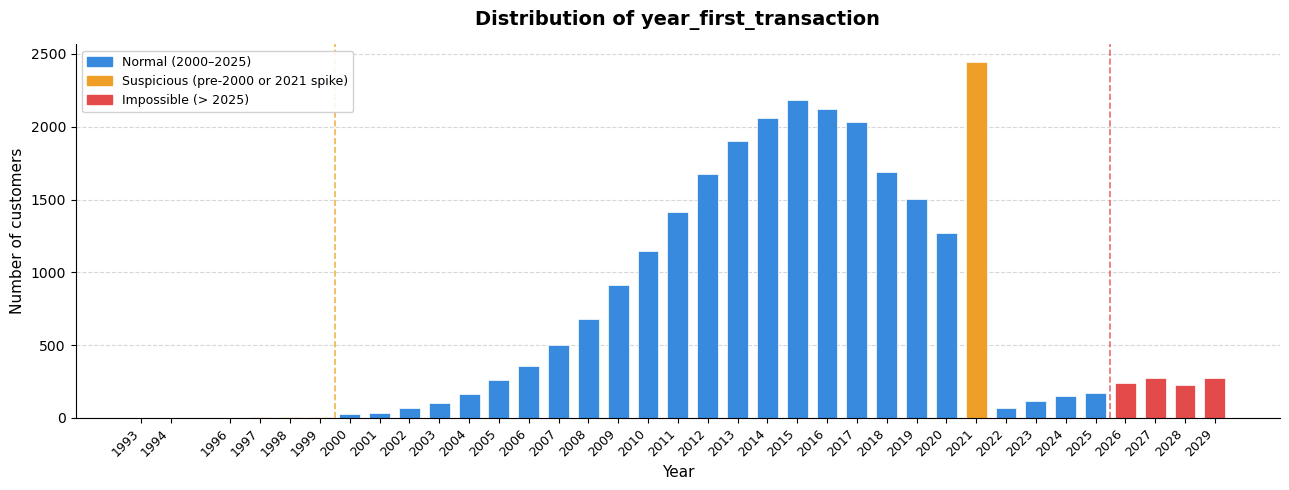

In [238]:
# --- plot ---
fig, ax = plt.subplots(figsize=(13, 5))

bars = ax.bar(year_counts.index.astype(int), year_counts.values, color=colors, width=0.7, edgecolor='white', linewidth=0.5)

ax.set_title('Distribution of year_first_transaction', fontsize=14, fontweight='bold', pad=14)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Number of customers', fontsize=11)
ax.set_xticks(year_counts.index.astype(int))
ax.set_xticklabels(year_counts.index.astype(int), rotation=45, ha='right', fontsize=9)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)

# --- vertical dividers ---
ax.axvline(x=1999.5, color='#EF9F27', linestyle='--', linewidth=1.2, alpha=0.8)
ax.axvline(x=2025.5, color='#E24B4A', linestyle='--', linewidth=1.2, alpha=0.8)

# --- legend ---
legend_handles = [
    mpatches.Patch(color='#378ADD', label='Normal (2000–2025)'),
    mpatches.Patch(color='#EF9F27', label='Suspicious (pre-2000 or 2021 spike)'),
    mpatches.Patch(color='#E24B4A', label='Impossible (> 2025)'),
]
ax.legend(handles=legend_handles, fontsize=9, loc='upper left', framealpha=0.9)

plt.tight_layout()
plt.show()

In [239]:
# --- percentages summary (printed below the plot) ---
pre2000  = (cust_info['year_first_transaction'] < 2000).sum()
future   = (cust_info['year_first_transaction'] > 2025).sum()
spike    = (cust_info['year_first_transaction'] == 2021).sum()
normal   = ((cust_info['year_first_transaction'] >= 2000) & (cust_info['year_first_transaction'] <= 2025)).sum()

print("=" * 45)
print(f"{'Category':<30} {'Rows':>6}  {'% total':>7}")
print("-" * 45)
print(f"{'Normal (2000–2025)':<30} {normal:>6,}  {normal/total*100:>6.1f}%")
print(f"{'2021 spike':<30} {spike:>6,}  {spike/total*100:>6.1f}%")
print(f"{'Pre-2000 (likely errors)':<30} {pre2000:>6,}  {pre2000/total*100:>6.1f}%")
print(f"{'Future dates > 2025':<30} {future:>6,}  {future/total*100:>6.1f}%")
print("=" * 45)
print(f"{'Total':<30} {total:>6,}  {'100.0%':>7}")

Category                         Rows  % total
---------------------------------------------
Normal (2000–2025)             25,036    96.0%
2021 spike                      2,443     9.4%
Pre-2000 (likely errors)           21     0.1%
Future dates > 2025             1,016     3.9%
Total                          26,073   100.0%


??????

## `loyalty_card_number`

In [240]:
print(cust_info['loyalty_card_number'].value_counts())

loyalty_card_number
1.0    15772
Name: count, dtype: int64


In [241]:
cust_info['loyalty_card_number'].isnull().sum()

np.int64(10301)

In [242]:
cust_info['has_loyalty_card'] = cust_info['loyalty_card_number'].notna().astype(int)
print(cust_info['has_loyalty_card'].value_counts())

has_loyalty_card
1    15772
0    10301
Name: count, dtype: int64


In [243]:
cust_info = cust_info.drop(columns=['loyalty_card_number'])
cust_info['has_loyalty_card'].head(10)

customer_id
7     1
8     1
11    1
12    0
14    1
15    1
16    1
18    1
19    1
20    1
Name: has_loyalty_card, dtype: int64

# Feature Engineering

| Feature | Formula | Interpretation |
|---|---|---|
| `alcoolic` | `lifetime_spend_alcohol_drinks × number_complaints` | Stressed/unsatisfied customers that drink more |
| `fresh_food_ratio` | `(lifetime_spend_vegetables + lifetime_spend_meat + lifetime_spend_fish) / total_spend` | Proportion of total spend on fresh food || `spend_per_store` | `lifetime_spend_groceries / distinct_stores_visited` | Average grocery spend per store visited |
| `promotion_on_stores_hunter` | `percentage_of_products_bought_promotion × distinct_stores_visited` | Customers that hunt deals across multiple stores |
| `promotion_guy` | `total_spend × percentage_of_products_bought_promotion` | High spenders that are still promotion-driven |
| `progenitores` | `kids_home + teens_home` | Total number of dependents at home |

In [244]:
cust_info['alcoolic_v1'] = cust_info['lifetime_spend_alcohol_drinks'] * cust_info['number_complaints']
cust_info['fresh_food_ratio'] = (cust_info['lifetime_spend_vegetables'] + cust_info['lifetime_spend_meat'] + cust_info['lifetime_spend_fish']) / cust_info['lifetime_spend_groceries']
cust_info['spend_per_store'] = cust_info['lifetime_spend_groceries'] / cust_info['distinct_stores_visited']
cust_info['promotion_on_stores_hunter'] = cust_info['percentage_of_products_bought_promotion'] * cust_info['distinct_stores_visited']
cust_info['promotion_guy'] = cust_info['lifetime_spend_groceries'] * cust_info['percentage_of_products_bought_promotion']
cust_info['progenitores'] = cust_info['kids_home'] + cust_info['teens_home']

In [245]:
cust_info.head(10)

,customer_name,customer_gender,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,...,longitude,education_level,age,has_loyalty_card,alcoolic_v1,fresh_food_ratio,spend_per_store,promotion_on_stores_hunter,promotion_guy,progenitores
customer_id,,,,,,,,,,,,,,,,,,,,,
7,John Kelling,male,0.0,0.0,2.0,1.0,7493.0,1105.0,18.0,84.0,...,-9.148679,None,43,1,2266.0,0.285466,7493.000000,0.253609,1900.294191,0.0
8,Arthur Dematteo,male,0.0,0.0,3.0,1.0,9187.0,10841.0,17.0,380.0,...,-9.188188,None,56,1,2154.0,0.268096,9187.000000,0.186569,1714.006967,0.0
11,Robert Hansing,male,1.0,1.0,1.0,6.0,29765.0,1543.0,10.0,190.0,...,-9.225047,Bsc,48,1,641.0,0.060205,4960.833333,0.985506,4888.930791,2.0
12,Dorothy Pacheco,female,0.0,0.0,0.0,2.0,9281.0,254.0,18.0,125.0,...,-9.167756,Phd,26,0,0.0,0.092878,4640.500000,0.262352,1217.444870,0.0
14,Arron Burgener,male,1.0,0.0,1.0,3.0,7981.0,2151.0,12.0,1659.0,...,-9.184158,Msc,77,1,125.0,0.229420,2660.333333,0.592058,1575.072722,1.0
15,Henry Thompson,male,0.0,1.0,0.0,3.0,7237.0,591.0,7.0,1807.0,...,-9.078360,Bsc,77,1,0.0,0.316015,2412.333333,0.333949,805.595327,1.0
16,Charlene Baird,female,0.0,0.0,1.0,7.0,11107.0,108.0,15.0,620.0,...,-9.152032,Bsc,25,1,182.0,0.198163,1586.714286,7.000000,11107.000000,0.0
18,Bruno Goldbeck,male,0.0,1.0,2.0,1.0,10490.0,13672.0,20.0,104.0,...,-9.156229,None,29,1,1410.0,0.199237,10490.000000,0.409140,4291.881468,1.0
19,Evelyn Quinn,female,1.0,2.0,3.0,3.0,8264.0,1660.0,19.0,266.0,...,-9.135196,Phd,78,1,1542.0,0.326113,2754.666667,0.472586,1301.816368,3.0


# Scaling

In [246]:
from sklearn.preprocessing import StandardScaler

# Columns to use for clustering
cluster_features = [
    'age',
    'number_complaints',
    'progenitores',                         # replaces kids_home + teens_home
    'spend_per_store',                      # replaces lifetime_spend_groceries + distinct_stores_visited
    'fresh_food_ratio',                     # replaces vegetables + meat + fish
    'lifetime_spend_electronics',
    'lifetime_spend_nonalcohol_drinks',
    'lifetime_spend_alcohol_drinks',
    'lifetime_spend_hygiene',
    'lifetime_spend_petfood',
    'lifetime_spend_videogames',
    'lifetime_total_distinct_products',
    'percentage_of_products_bought_promotion',
    'alcoolic_v1',
    'promotion_on_stores_hunter',
    'has_loyalty_card',
]

X = cust_info[cluster_features]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=cluster_features,
    index=cust_info.index
)

X_scaled.head()

,age,number_complaints,progenitores,spend_per_store,fresh_food_ratio,lifetime_spend_electronics,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_hygiene,lifetime_spend_petfood,lifetime_spend_videogames,lifetime_total_distinct_products,percentage_of_products_bought_promotion,alcoolic_v1,promotion_on_stores_hunter,has_loyalty_card
customer_id,,,,,,,,,,,,,,,,
7,-0.643193,1.191696,-1.133537,0.084108,-0.023774,-0.482093,1.060282,0.987470,-0.553259,-0.948311,2.771467,-0.536222,-0.289605,1.895829,-0.712061,0.808158
8,0.075301,2.309080,-1.133537,0.333909,-0.027400,2.350506,0.461413,0.185337,-0.861135,0.651486,1.910695,-1.347570,-0.539697,1.766506,-0.766507,0.808158
11,-0.366849,0.074312,-0.010936,-0.289289,-0.070798,-0.354661,-0.195528,0.036508,0.683157,0.377591,3.188877,0.293996,-0.622952,0.019490,-0.117658,0.808158
12,-1.582762,-1.043072,-1.133537,-0.336526,-0.063978,-0.729683,-1.469486,1.791536,-0.245383,-1.695297,-0.656481,-1.130582,-0.746337,-0.720654,-0.704961,-1.237382
14,1.235945,0.074312,-0.572237,-0.628525,-0.035474,-0.177769,1.212721,-0.960843,0.933716,-1.533450,-0.425067,-0.866422,-0.499467,-0.576320,-0.437193,0.808158


# Dimensionality Reduction & Manifold Learning

These methods aim to reduce the number of variables while preserving as much relevant information as possible. They are mainly used for visualization, noise reduction, feature extraction, and preprocessing before modeling.

## Principal Component Analysis (PCA)
PCA is a linear dimensionality reduction technique that transforms the data into a new coordinate system.
- New variables are called **principal components**.
- Components are orthogonal and ordered by explained variance.
- Maximizes variance, not class separation.
- Sensitive to scaling, variables should be standardized.
- Useful for compression, denoising, and exploratory analysis.
- Assumes linear relationships in the data.

## t-SNE (t-Distributed Stochastic Neighbor Embedding)
t-SNE is a nonlinear technique focused on preserving local structure.
- Maps high-dimensional data into 2D or 3D for visualization.
- Preserves neighborhood relationships.
- Very effective at revealing clusters visually.
- Distances between far points are not meaningful.
- Computationally expensive for large datasets.
- Results depend heavily on hyperparameters (perplexity, learning rate).
- Not suitable for downstream modeling or interpretation.

## UMAP (Uniform Manifold Approximation and Projection)
UMAP is a nonlinear manifold learning technique designed for visualization and structure preservation.
- Preserves both local and some global structure.
- Faster and more scalable than t-SNE.
- Produces more stable embeddings.
- Can be used as a preprocessing step for clustering.
- Based on manifold theory and graph construction.
- Hyperparameters control local vs global emphasis (n_neighbors, min_dist).

## Comparison Overview
- **PCA**: linear, interpretable, variance-based.
- **t-SNE**: nonlinear, visualization-focused, local structure only.
- **UMAP**: nonlinear, visualization + clustering-friendly, scalable.

## Typical Use Cases
- PCA: feature reduction before regression or classification.
- t-SNE: exploratory visualization of high-dimensional data.
- UMAP: visualization and clustering support in large datasets.

# PCA

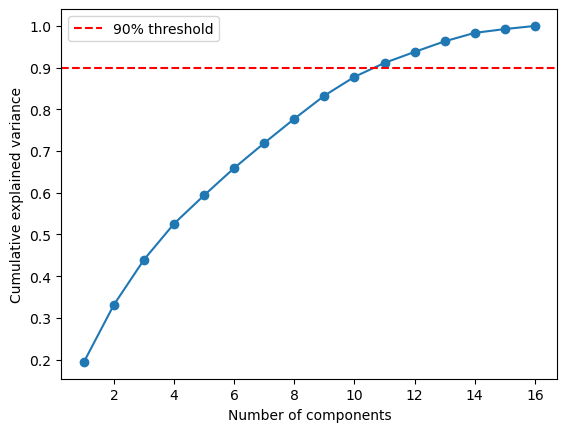

In [247]:
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(X_scaled)

cumvar = np.cumsum(pca.explained_variance_ratio_)
plt.plot(range(1, len(cumvar)+1), cumvar, marker='o')
plt.axhline(0.9, linestyle='--', color='red', label='90% threshold')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.legend()
plt.show()

13 variables explain 90% of all variance

In [250]:
pca = PCA(n_components=13, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Explained variance: {pca.explained_variance_ratio_.sum():.2%}")

Explained variance: 96.30%


In [251]:
X_scaled.to_csv('X_scaled.csv', index=True)